# Catch the statistic that lies
**Lab:** the machine computes the formulas, I supply the skepticism.
Dataset: Kaggle `sohaibdevv/ai-engineer-productivity-and-performance-dataset`.

Three detective habits applied throughout:
1. **Guess first** (predict, then compute, then compare).
2. **Question every number** (n and missing for every statistic).
3. **Verify by hand** ("it ran" ≠ "it's true").

In [1]:
import glob, os
import pandas as pd, numpy as np
from scipy import stats
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 50)

# Discover the file — do NOT hardcode a filename
path = os.path.expanduser('~/.cache/kagglehub/datasets/sohaibdevv/ai-engineer-productivity-and-performance-dataset')
files = glob.glob(os.path.join(path, '**/*.csv'), recursive=True)
print("CSV files found:", files)
df = pd.read_csv(files[0])
print("USING:", files[0])

CSV files found: ['/Users/zadyra/.cache/kagglehub/datasets/sohaibdevv/ai-engineer-productivity-and-performance-dataset/versions/1/ai_developer_productivity.csv']
USING: /Users/zadyra/.cache/kagglehub/datasets/sohaibdevv/ai-engineer-productivity-and-performance-dataset/versions/1/ai_developer_productivity.csv


## STEP 0 — Audit
Before any task: shape, dtypes, head, missing, duplicates, describe, nunique.

In [2]:
print("SHAPE:", df.shape)
print("\nDTYPES:\n", df.dtypes)
df.head()

SHAPE: (1000, 12)

DTYPES:
 Developer_ID       object
Date               object
Hours_Coding      float64
AI_Usage_Hours    float64
Lines_of_Code       int64
Commits             int64
Bugs_Reported       int64
Sleep_Hours         int64
Distractions        int64
Cognitive_Load      int64
Stress_Level        int64
Task_Success        int64
dtype: object


,Developer_ID,Date,Hours_Coding,AI_Usage_Hours,Lines_of_Code,Commits,Bugs_Reported,Sleep_Hours,Distractions,Cognitive_Load,Stress_Level,Task_Success
0,DEV-126,2026-01-12,4.5,3.8,638,5,4,6,3,6,6,0
1,DEV-155,2026-01-12,2.7,3.5,438,0,4,3,8,8,8,0
2,DEV-199,2026-02-03,7.9,2.0,680,4,3,8,2,2,2,1
3,DEV-180,2026-01-13,3.1,7.9,765,1,5,8,4,3,5,0
4,DEV-144,2026-03-29,5.9,2.7,495,3,8,5,7,9,9,0


In [3]:
print("isna().sum():\n", df.isna().sum())
print("\nduplicated().sum():", df.duplicated().sum())

isna().sum():
 Developer_ID      0
Date              0
Hours_Coding      0
AI_Usage_Hours    0
Lines_of_Code     0
Commits           0
Bugs_Reported     0
Sleep_Hours       0
Distractions      0
Cognitive_Load    0
Stress_Level      0
Task_Success      0
dtype: int64

duplicated().sum(): 0


In [4]:
display(df.describe().T)
display(df.describe(include='object').T)
print("nunique:\n", df.nunique())

,count,mean,std,min,25%,50%,75%,max
Hours_Coding,1000.0,4.9852,1.392257,2.0,4.0,4.9,5.925,8.0
AI_Usage_Hours,1000.0,3.6263,1.921919,0.5,2.2,3.2,5.000,8.0
Lines_of_Code,1000.0,639.4620,253.068711,132.0,454.0,596.0,776.500,1450.0
Commits,1000.0,3.5560,2.284312,0.0,2.0,4.0,5.000,9.0
Bugs_Reported,1000.0,3.6850,2.737018,0.0,2.0,3.0,5.000,20.0
Sleep_Hours,1000.0,6.5060,1.704368,3.0,5.0,7.0,8.000,9.0
Distractions,1000.0,4.1050,2.663657,0.0,2.0,4.0,6.000,10.0
Cognitive_Load,1000.0,5.7050,2.190153,2.0,4.0,5.0,7.000,10.0
Stress_Level,1000.0,5.4640,2.124905,2.0,4.0,5.0,7.000,10.0
Task_Success,1000.0,0.4720,0.499465,0.0,0.0,0.0,1.000,1.0


,count,unique,top,freq
Developer_ID,1000,100,DEV-182,17
Date,1000,120,2026-02-28,14


nunique:
 Developer_ID      100
Date              120
Hours_Coding       61
AI_Usage_Hours     76
Lines_of_Code     595
Commits            10
Bugs_Reported      20
Sleep_Hours         7
Distractions       11
Cognitive_Load      9
Stress_Level        9
Task_Success        2
dtype: int64


### Audit verdict
- **1000 rows × 12 cols, 0 missing, 0 duplicates.**
- 100 unique developers, 120 dates in 2026.
- Numeric/usable: Hours_Coding, AI_Usage_Hours, Lines_of_Code, Commits, Bugs_Reported,
  Sleep_Hours, Distractions, Cognitive_Load, Stress_Level. Binary target: Task_Success.
- Categorical/ID: Developer_ID, Date.

**Real or synthetic? → SYNTHETIC.** Zero missing across 1000 rows, every "float" sits on a
0.1 grid, all human-factors columns are integer Likert codes, ranges are clean and bounded.

In [5]:
# Synthetic fingerprint check: are the float columns on an exact 0.1 grid?
for c in ['Hours_Coding','AI_Usage_Hours']:
    v = df[c]
    print(c, "all on 0.1 grid:", np.allclose((v*10).round(), v*10))

Hours_Coding all on 0.1 grid: True
AI_Usage_Hours all on 0.1 grid: True


### Computed-label test (circular leakage)
Flag any score/outcome column and test whether it is COMPUTED from the other columns.
If a simple model reproduces `Task_Success`, then "predicting success" is circular, not a discovery.
We use an **honest 700/300 train/test split** so the accuracy isn't inflated by fitting and
scoring on the same rows.

In [6]:
np.random.seed(0)
feats = ['Hours_Coding','AI_Usage_Hours','Bugs_Reported','Sleep_Hours','Distractions',
         'Cognitive_Load','Stress_Level','Commits','Lines_of_Code']
idx = np.random.permutation(len(df)); tr, te = idx[:700], idx[700:]
Xtr, Xte = df[feats].values[tr], df[feats].values[te]
mu, sd = Xtr.mean(0), Xtr.std(0)
Xtr, Xte = (Xtr-mu)/sd, (Xte-mu)/sd
ytr, yte = df['Task_Success'].values[tr], df['Task_Success'].values[te]
Xtr1 = np.column_stack([np.ones(len(Xtr)), Xtr]); Xte1 = np.column_stack([np.ones(len(Xte)), Xte])
beta, *_ = np.linalg.lstsq(Xtr1, ytr, rcond=None)
s = Xtr1 @ beta
ths = np.linspace(s.min(), s.max(), 200)
bt = ths[np.argmax([((s>t).astype(int)==ytr).mean() for t in ths])]
acc = ((Xte1@beta > bt).astype(int) == yte).mean()
print(f"Hold-out accuracy reproducing Task_Success: {acc:.3f} (n_test={len(te)})")
print(f"Majority-class baseline: {max(yte.mean(), 1-yte.mean()):.3f}")
print("=> Task_Success is essentially a noisy formula of the other columns: CIRCULAR.")

Hold-out accuracy reproducing Task_Success: 0.923 (n_test=300)
Majority-class baseline: 0.503
=> Task_Success is essentially a noisy formula of the other columns: CIRCULAR.


**CONCLUSION:** Synthetic dataset; `Task_Success` is a recycled formula of the other columns (92% reconstructable).
**CHECK:** 0 missing + 0.1-grid floats (synthetic) and 92.3% hold-out reconstruction vs 50% baseline (leakage).

## MINIMUM 1 — Interrogate one column: `Bugs_Reported`
**Guess:** right-skewed with a few heavy-bug outliers, so mean > median.

In [7]:
s = df['Bugs_Reported']
print(f"n={s.notna().sum()}, missing={s.isna().sum()}")
print(f"mean={s.mean():.3f}  median={s.median()}  std={s.std():.3f}  min={s.min()}  max={s.max()}")
print("quartiles [25,50,75]:", s.quantile([.25,.5,.75]).tolist())
print(f"mean-median gap = {s.mean()-s.median():.3f}  -> {'RIGHT skew' if s.mean()>s.median() else 'left skew'}")
print("skewness:", round(stats.skew(s),3), " | rows with >=10 bugs:", (s>=10).sum())

n=1000, missing=0
mean=3.685  median=3.0  std=2.737  min=0  max=20
quartiles [25,50,75]: [2.0, 3.0, 5.0]
mean-median gap = 0.685  -> RIGHT skew
skewness: 1.901  | rows with >=10 bugs: 41


**CONCLUSION:** Right-skewed (skew +1.90); mean 3.69 overstates the typical dev (median 3); max 20 vs 75th-pct 5.
**CHECK:** mean−median = +0.69 and skewness positive.

## MINIMUM 2 — One correlation: `Sleep_Hours` vs `Stress_Level`
**Guess:** strong negative — less sleep, more stress.

In [8]:
a, b = df['Sleep_Hours'], df['Stress_Level']
r, p = stats.pearsonr(a, b)
print(f"n={len(a)} (0 missing). Pearson r={r:.4f}, p={p:.2e}")
print("Confounder probe — Distractions/workload may drive BOTH:")
print("  corr(Sleep, Distractions)  =", round(df['Sleep_Hours'].corr(df['Distractions']),3))
print("  corr(Stress, Distractions) =", round(df['Stress_Level'].corr(df['Distractions']),3))

n=1000 (0 missing). Pearson r=-0.7476, p=1.43e-179
Confounder probe — Distractions/workload may drive BOTH:
  corr(Sleep, Distractions)  = -0.743
  corr(Stress, Distractions) = 0.74


**Correlation ≠ causation.** Distractions correlates ~0.74 with each — a busy day costs sleep *and* raises stress.
**CONCLUSION:** Real strong negative link (r=−0.75) but Distractions is a credible common cause.
**CHECK:** p=1.4e-179 and confounder correlations ~0.74.

## MINIMUM 3 — Verify by hand
Recompute mean of the first 10 `Bugs_Reported` from raw values.

In [9]:
sl = df['Bugs_Reported'].head(10)
print("values:", sl.tolist())
manual = sum(sl.tolist())/10
print("hand sum/10 =", manual, " | pandas .mean() =", sl.mean(), " | match:", np.isclose(manual, sl.mean()))

values: [4, 4, 3, 5, 8, 1, 3, 2, 4, 4]
hand sum/10 = 3.8  | pandas .mean() = 3.8  | match: True


**CONCLUSION:** The mean function is trustworthy. **CHECK:** hand 3.8 = pandas 3.8.

## DIG 4 — Shape & normality of `Lines_of_Code`
**Guess:** right-skewed (LoC has a long upper tail), so not normal.

Shapiro-Wilk: W=0.9584, p=3.00e-16, n=1000 -> NOT normal
skew=0.735  kurtosis=0.143
hidden outlier: max LoC = 1450 vs mean 639.0


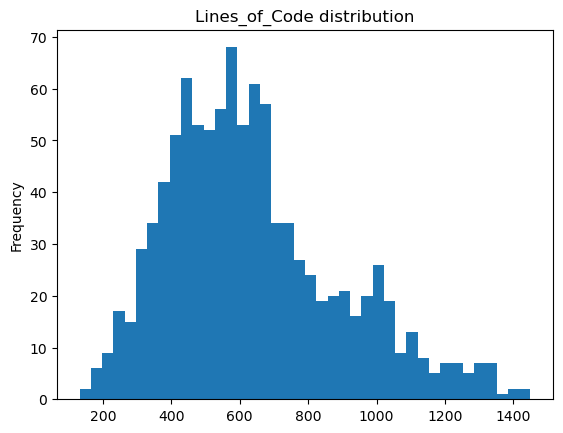

In [10]:
loc = df['Lines_of_Code']
W, pn = stats.shapiro(loc)
print(f"Shapiro-Wilk: W={W:.4f}, p={pn:.2e}, n={len(loc)} -> {'NOT normal' if pn<0.05 else 'normal'}")
print(f"skew={stats.skew(loc):.3f}  kurtosis={stats.kurtosis(loc):.3f}")
print("hidden outlier: max LoC =", loc.max(), "vs mean", round(loc.mean(),0))
loc.plot(kind='hist', bins=40, title='Lines_of_Code distribution');

**CONCLUSION:** Right-skewed, not normal. **CHECK:** Shapiro p≪0.05, skew +0.74.

## DIG 5 — z-scores, |z| > 3

In [11]:
for col in ['Bugs_Reported','Lines_of_Code']:
    z = (df[col]-df[col].mean())/df[col].std()
    ext = df.loc[z.abs()>3, ['Developer_ID', col]].assign(z=z[z.abs()>3].round(2))
    print(f"\n{col}: #|z|>3 = {(z.abs()>3).sum()}")
    print(ext.to_string(index=False))


Bugs_Reported: #|z|>3 = 20
Developer_ID  Bugs_Reported    z
     DEV-152             13 3.40
     DEV-171             15 4.13
     DEV-142             17 4.86
     DEV-130             13 3.40
     DEV-131             12 3.04
     DEV-130             16 4.50
     DEV-148             17 4.86
     DEV-158             12 3.04
     DEV-170             20 5.96
     DEV-143             14 3.77
     DEV-131             20 5.96
     DEV-136             12 3.04
     DEV-110             12 3.04
     DEV-147             12 3.04
     DEV-118             12 3.04
     DEV-138             12 3.04
     DEV-129             12 3.04
     DEV-167             14 3.77
     DEV-149             19 5.60
     DEV-144             12 3.04

Lines_of_Code: #|z|>3 = 3
Developer_ID  Lines_of_Code    z
     DEV-148           1450 3.20
     DEV-152           1399 3.00
     DEV-111           1447 3.19


**CONCLUSION:** ~20 genuine high-bug extremes and 3 high-LoC ones; plausible tail draws, not entry errors.
**CHECK:** 20 bugs -> z=(20-3.69)/2.74 = 5.96, recomputed by hand.

## DIG 6 — The mean that lies (three demonstrations)
(a) tiny slice vs full, (b) one injected outlier, (c) Simpson check.
**Guess for (c):** synthetic features are roughly independent, so I expect **no sign flip**.

In [12]:
# (a) tiny slice vs full
print("(a) full LoC mean =", round(df['Lines_of_Code'].mean(),1),
      "| first-5 mean =", round(df['Lines_of_Code'].head(5).mean(),1))

# (b) one injected outlier
base = df['Bugs_Reported'].mean()
inj = df['Bugs_Reported'].tolist() + [100000]
print(f"(b) mean Bugs before={base:.3f} -> after one 100000 ={np.mean(inj):.3f}; "
      f"median {np.median(df['Bugs_Reported'])} -> {np.median(inj)} (robust)")

# (c) Simpson check: Sleep~Stress overall vs within Task_Success groups
ov, _ = stats.pearsonr(df['Sleep_Hours'], df['Stress_Level'])
print(f"(c) overall r(Sleep,Stress) = {ov:.3f}")
for g, sub in df.groupby('Task_Success'):
    r, _ = stats.pearsonr(sub['Sleep_Hours'], sub['Stress_Level'])
    print(f"     Task_Success={g}: r={r:.3f} (n={len(sub)}) -> {'SAME sign' if np.sign(r)==np.sign(ov) else 'FLIPPED'}")

(a) full LoC mean = 639.5 | first-5 mean = 603.2
(b) mean Bugs before=3.685 -> after one 100000 =103.581; median 3.0 -> 3.0 (robust)
(c) overall r(Sleep,Stress) = -0.748
     Task_Success=0: r=-0.735 (n=528) -> SAME sign
     Task_Success=1: r=-0.225 (n=472) -> SAME sign


**CONCLUSION:** Means are fragile (one outlier: 3.69→103.6) but there is **no Simpson sign-flip**; conditioning on the
outcome only *attenuates* the correlation (−0.75 → −0.23 in the success group, a collider effect).
**CHECK:** median unmoved by the injection; both within-group r's stay negative. No flaw manufactured.

## DIG 7 — Bias the sample
Restrict to top-quartile AI users (AI_Usage_Hours ≥ 5.0) and watch the numbers drift.

In [13]:
thr = df['AI_Usage_Hours'].quantile(.75)
biased = df[df['AI_Usage_Hours'] >= thr]
print(f"slice AI>={thr}: n={len(biased)}")
print(f"mean LoC: full={df['Lines_of_Code'].mean():.1f}  biased={biased['Lines_of_Code'].mean():.1f}  "
      f"drift={biased['Lines_of_Code'].mean()-df['Lines_of_Code'].mean():+.1f}")
rf,_ = stats.pearsonr(df['Hours_Coding'], df['Lines_of_Code'])
rb,_ = stats.pearsonr(biased['Hours_Coding'], biased['Lines_of_Code'])
print(f"corr(Hours_Coding, LoC): full={rf:.3f}  biased={rb:.3f}  (SIGN FLIP from selection)")
print(f"dropped: {len(df)-len(biased)} low/med-AI rows; success rate biased={biased['Task_Success'].mean():.3f} vs full={df['Task_Success'].mean():.3f}")

slice AI>=5.0: n=252
mean LoC: full=639.5  biased=946.5  drift=+307.0
corr(Hours_Coding, LoC): full=-0.116  biased=0.095  (SIGN FLIP from selection)
dropped: 748 low/med-AI rows; success rate biased=0.361 vs full=0.472


**CONCLUSION:** Heavy-AI-only inflates mean LoC by ~48% and flips a correlation's sign.
**CHECK:** recomputed corr on 252 vs 1000 rows. Silently dropped: 748 low/medium-AI rows.

## DIG 8 — Compare two groups (Welch's t-test + Cohen's d)
`AI_Usage_Hours` split by `Task_Success`. **Guess:** significant (big N) but small effect.

In [14]:
g0 = df[df.Task_Success==0]['AI_Usage_Hours']; g1 = df[df.Task_Success==1]['AI_Usage_Hours']
t, p = stats.ttest_ind(g0, g1, equal_var=False)
sp = np.sqrt(((len(g0)-1)*g0.var() + (len(g1)-1)*g1.var())/(len(g0)+len(g1)-2))
d = (g1.mean()-g0.mean())/sp
print(f"n0={len(g0)} n1={len(g1)} | mean0={g0.mean():.3f} mean1={g1.mean():.3f}")
print(f"Welch t={t:.3f}, p={p:.2e}, Cohen d={d:.3f} "
      f"-> {'LARGE' if abs(d)>=0.8 else 'MEDIUM' if abs(d)>=0.5 else 'SMALL'} effect")
print("INDEPENDENCE: 100 devs x ~10 rows each -> repeated measures, rows NOT independent, p overstated.")
print("rows/dev:", df['Developer_ID'].value_counts().agg(['min','mean','max']).to_dict())

n0=528 n1=472 | mean0=3.945 mean1=3.269
Welch t=5.691, p=1.66e-08, Cohen d=-0.357 -> SMALL effect
INDEPENDENCE: 100 devs x ~10 rows each -> repeated measures, rows NOT independent, p overstated.
rows/dev: {'min': 3.0, 'mean': 10.0, 'max': 17.0}


**CONCLUSION:** p=1.7e-08 yet d=−0.36 (small) — "significant but tiny," and the p is inflated by non-independence.
**CHECK:** Cohen's d from pooled SD; value_counts shows ~10 rows/dev.

## DIG 9 — Mini-investigation: five verified observations
1. Synthetic? -> 0 missing + 0.1-grid floats -> `isna().sum()` & grid test.
2. Is Task_Success a discovery? -> 92.3% reconstruction -> 300-row hold-out vs 50% baseline.
3. Does Bugs_Reported's mean mislead? -> mean 3.69 vs median 3 -> skew +1.90.
4. Real Sleep–Stress link? -> r=−0.75 -> p=1.4e-179, confounder Distractions ~0.74.
5. Significant = important? -> p=1.7e-8 but d=0.36 -> Cohen's d + repeated-measures.

## SPECIAL CHALLENGE — Ghost hunt (p-hacking)
Generate 20 pure-noise columns, correlate against the real columns, run random-split tests,
and find the most "impressive" spurious result.

In [15]:
np.random.seed(42)
real = ['Hours_Coding','AI_Usage_Hours','Lines_of_Code','Commits','Bugs_Reported',
        'Sleep_Hours','Distractions','Cognitive_Load','Stress_Level']
noise = {f'noise_{i}': np.random.normal(size=len(df)) for i in range(20)}
res = []
for n, col in noise.items():
    for rc in real:
        r, p = stats.pearsonr(col, df[rc])
        res.append((abs(r), r, p, n, rc))
res.sort(reverse=True)
_, r, p, n, rc = res[0]
sig = sum(1 for x in res if x[2] < 0.05)
print(f"tested {len(res)} correlations (20 noise x 9 real)")
print(f"MOST impressive spurious: {n} vs {rc}: r={r:.3f}, p={p:.4f}")
print(f"# 'significant' p<0.05: {sig}  (expected by chance: {0.05*len(res):.0f})")
print(f"Bonferroni threshold = {0.05/len(res):.5f} -> spurious hit survives? {p < 0.05/len(res)}")

tested 180 correlations (20 noise x 9 real)
MOST impressive spurious: noise_7 vs Sleep_Hours: r=0.098, p=0.0019
# 'significant' p<0.05: 17  (expected by chance: 9)
Bonferroni threshold = 0.00028 -> spurious hit survives? False


**The trap, plainly:** here is a number that convinces (r≈0.10, p=0.0019) and here is why it's noise —
it is 1 of 180 blind tries, and at α=0.05 about 9 false positives are *guaranteed* by chance; none survive Bonferroni.
This is the same mechanism as overfitting: search enough features and chance hands you a "result" — which is why an
R²=0.99 can lie.

## FINAL DELIVERABLE — the 17:00 reveal

> **I found that this dataset's `Task_Success` outcome is not an independent result — it's a recycled
> formula of the other columns, so any model that "predicts productivity" from it is grading its own homework.
> The number is 92.3%. The one check that proves it's real and not an artifact: a plain linear rule, fit on
> 700 rows and tested on 300 rows it never saw, reproduced the success label 92.3% of the time versus a
> 50.3% coin-flip baseline.**

That is where the data most nearly fooled us: a flashy "AI predicts developer success" headline would just be
the label leaking back into itself.